In [1]:
## 加载所需要的模块，配置运行环境
#加载数据处理和分析模块
import pandas as pd
#科学运算模块
import numpy as np
#限制运行进程为单进程，避免当数据量过大时内存消耗过大导致内存不足，无法运行
import os
os.environ["OMP_NUM_THREADS"] = "1" 
#绘图模块
import matplotlib.pyplot as plt
#载入K均值聚类的相关模块
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score

In [2]:
##载入国家风险数据
#读取excel文件（注意csv文件需要用read_csv()读取)
raw=pd.read_excel(r'C:\Users\molam\Desktop\countryriskdata.xlsx')
#输出新赋值变量raw前5行，进行查看，是否与excel一致print(raw)
print('\n显示前5行\n',raw.head())
#将国家缩写作为索引，并且删除国家列保持输出DataFrame的美观性
raw_new=raw.drop(columns=['Country'])
raw_new=raw_new.set_index('Abbrev')
print(raw_new.head())
#方便后续操作使用默认索引，并删除国家缩写
raw_new=raw_new.reset_index().drop(columns=['Abbrev'])
print(raw_new.head())


显示前5行
      Country Abbrev  Corruption  Peace  Legal  GDP Growth
0    Albania     AL          39  1.867  3.822       3.403
1    Algeria     DZ          34  2.213  4.160       4.202
2  Argentina     AR          36  1.957  4.568      -2.298
3    Armenia     AM          33  2.218  4.126       0.208
4  Australia     AU          79  1.465  8.244       2.471
        Corruption  Peace  Legal  GDP Growth
Abbrev                                      
AL              39  1.867  3.822       3.403
DZ              34  2.213  4.160       4.202
AR              36  1.957  4.568      -2.298
AM              33  2.218  4.126       0.208
AU              79  1.465  8.244       2.471
   Corruption  Peace  Legal  GDP Growth
0          39  1.867  3.822       3.403
1          34  2.213  4.160       4.202
2          36  1.957  4.568      -2.298
3          33  2.218  4.126       0.208
4          79  1.465  8.244       2.471



描述性统计
        Corruption       Peace       Legal  GDP Growth
count  121.000000  121.000000  121.000000  121.000000
mean    46.115702    2.005521    5.585066    2.380587
std     19.158197    0.449249    1.485655    3.253686
min     14.000000    1.192000    2.728000  -18.000000
25%     31.000000    1.680000    4.568000    1.433000
50%     40.000000    1.975000    5.217000    2.500000
75%     58.000000    2.284000    6.422000    4.093000
max     90.000000    3.399000    8.633000    7.958000
            Corruption     Peace     Legal  GDP Growth
Corruption    1.000000 -0.699785  0.923513    0.104738
Peace        -0.699785  1.000000 -0.651496   -0.201334
Legal         0.923513 -0.651496  1.000000    0.126955
GDP Growth    0.104738 -0.201334  0.126955    1.000000


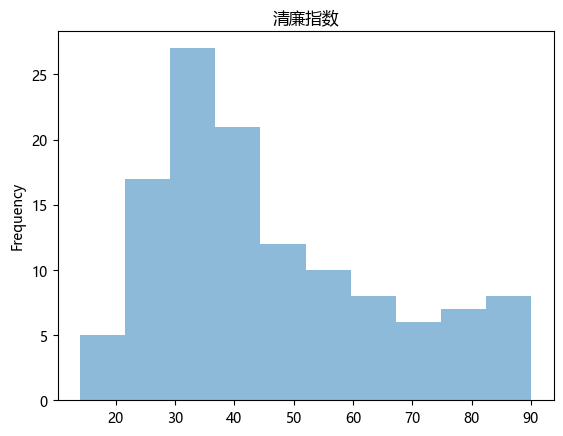

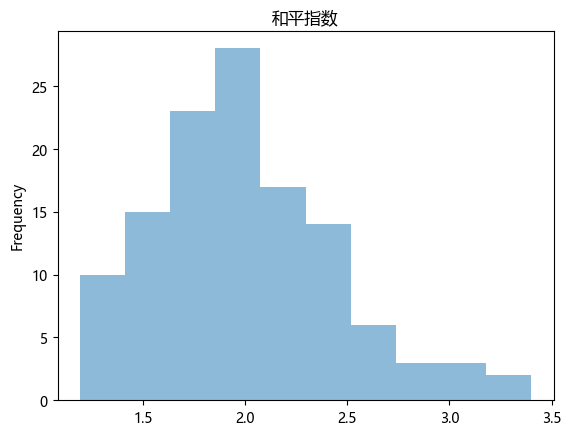

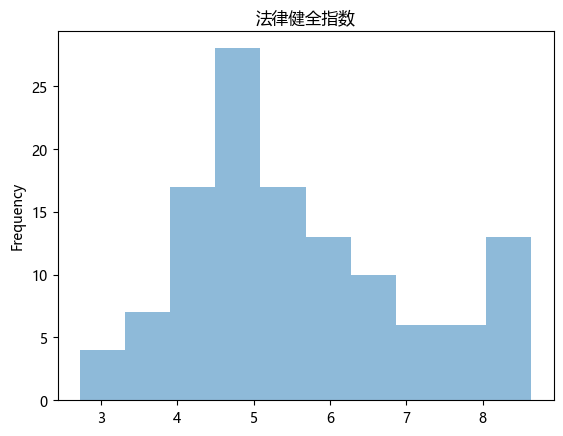

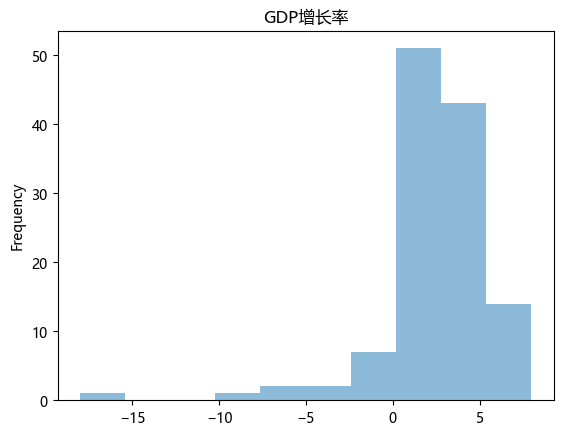

   Peace  Legal  GDP Growth
0  1.867  3.822       3.403
1  2.213  4.160       4.202
2  1.957  4.568      -2.298
3  2.218  4.126       0.208
4  1.465  8.244       2.471


In [3]:
#得出描述性统计结果
print('\n描述性统计\n',raw.describe())
#衡量四个特征之间的两两相关性
print(raw_new.corr())
# 通过将字体设置为Microsoft YaHei，避免中文无法显示 
plt.rcParams['font.sans-serif']='Microsoft YaHei'
#绘制直方图
plt.figure(1)
raw['Corruption'].plot(kind='hist',title='清廉指数',alpha=0.5)
plt.figure(2)
raw['Peace'].plot(kind='hist',title='和平指数',alpha=0.5,linestyle='--')
plt.figure(3)
raw['Legal'].plot(kind='hist',title='法律健全指数',alpha=0.5)
plt.figure(4)
raw['GDP Growth'].plot(kind='hist',title='GDP增长率',alpha=0.5)
plt.show()
#由于Corruption和Legal的相关性过高，故删除相关度过高的特征-Corruption
#需要访问多列数据，需要将包含对应列索引的<列表>传入DataFrame的中括号里
X=raw[['Peace','Legal','GDP Growth']]
print(X.head())

In [4]:
##进行数据清洗，避免表格出现脏数据
#浏览数据集，检查缺失值
raw_new.info()
#4列121行均非空值，无需删除drop()或补充fillna()缺失值
#检查异常值（基于历史数据判断，但某些异常数据可能是正常的，由不同国家内部极端事件导致，故筛选后要进行进一步判断）
#由于上面的描述性统计表格可以看出，这些数据不符合正态分布，故我在这里采取四分位距法IQR进行判断
#减少重复代码，选择定义函数
def detect(data, column):
    Q1=data[column].quantile(0.25)
    Q3=data[column].quantile(0.75)
    IQR=Q3-Q1
    low=Q1-1.5*IQR
    up=Q3+1.5*IQR
    outliers = data[(data[column] < low) | (data[column] > up)]
    #格式化输出异常范围，保留2位小数
    print(f"指标 {column} 的异常值范围: < {low:.2f} 或 > {up:.2f}")
    return outliers
# 对每个指标应用IQR方法
for i in ['Corruption', 'Peace', 'Legal', 'GDP Growth']:
    outlier_df = detect(raw_new,i)
    print(outlier_df)
#显然Corruption，Legal返回空表格没有问题
#分析Peace的异常值，通过其索引从原始数据中找到对应的国家
print(f"Peace异常的国家\n{raw.loc[[111,118],'Country']}")
#分析GDP Growth的异常值，通过其索引从原始数据中找到对应的国家
print(f"Peace异常的国家\n{raw.loc[[6,14,19,107,116,118],'Country']}")
#通过浏览器搜索这些国家的数据，及其原因
#经查证Venezuela面临政治动荡，油价下降等因素，GDP一直暴跌，为正常数据，不予删除（其余数据也均为合理的异常值）

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121 entries, 0 to 120
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Corruption  121 non-null    int64  
 1   Peace       121 non-null    float64
 2   Legal       121 non-null    float64
 3   GDP Growth  121 non-null    float64
dtypes: float64(3), int64(1)
memory usage: 3.9 KB
指标 Corruption 的异常值范围: < -9.50 或 > 98.50
Empty DataFrame
Columns: [Corruption, Peace, Legal, GDP Growth]
Index: []
指标 Peace 的异常值范围: < 0.77 或 > 3.19
     Corruption  Peace  Legal  GDP Growth
111          29  3.287  3.424       2.308
118          14  3.399  2.728      -9.779
指标 Legal 的异常值范围: < 1.79 或 > 9.20
Empty DataFrame
Columns: [Corruption, Peace, Legal, GDP Growth]
Index: []
指标 GDP Growth 的异常值范围: < -2.56 或 > 8.08
     Corruption  Peace  Legal  GDP Growth
6            30  2.450  3.946      -3.772
14           40  2.176  5.434      -3.595
19           20  2.464  3.891      -6.373
107          

[1559.4559410082643, 1032.036087359252, 582.2217142530636, 400.56776824665155, 278.8459643427778, 231.32564405349217, 190.20304117823244, 163.80949506414944, 146.1132813197479]


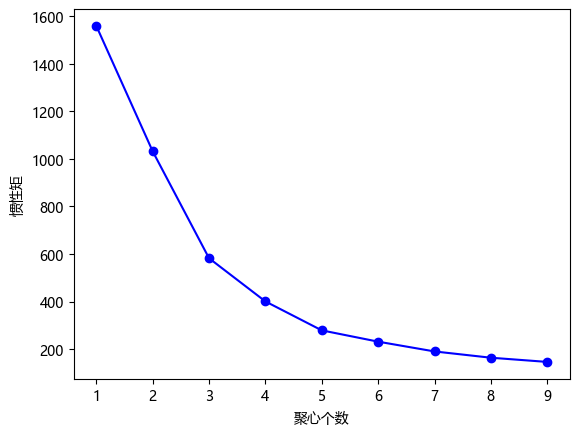

inertia for k=3 is 582.2217142530636
cluster centers:  [[ 2.10439216  4.93898039  4.59801961]
 [ 1.8773125   6.24067188  1.56532813]
 [ 2.53266667  4.08366667 -7.7715    ]]
     和平指数  法律风险指数  GDP增长率(%)
高风险  2.53    4.08      -7.77
中风险  2.10    4.94       4.60
低风险  1.88    6.24       1.57


In [5]:
##K均值聚类
# 设置随机种子（确保可复现）
from numpy import random
random.seed(1)
#尝试不同的子聚类个数，观察惯性矩的数值变化
Ks=range(1,10)
inertia=[KMeans(i).fit(X).inertia_ for i in Ks]
print(inertia)
#画出惯性矩分布图
#inertia_series = pd.Series(inertia, index=Ks)
plt.figure(5)
plt.plot(Ks,inertia, '-bo')
plt.xlabel('聚心个数')
plt.ylabel('惯性矩')
plt.show()
#令子聚类个数=3，即将国家分为高-中-低三类不同的情况
k = 3
#计算在特征缩放之前高、中、低风险国家的子聚类中心
kmeans = KMeans(n_clusters=k, random_state=1)
kmeans.fit(X)
# 每样本点到其所属簇中心的距离的平方和
print("inertia for k=3 is", kmeans.inertia_)
#子聚类中心
print("cluster centers: ", kmeans.cluster_centers_)
#转换为DataFrame格式
cluster_centers=pd.DataFrame(kmeans.cluster_centers_)
#修改子聚类中心的行列索引方便观察
#修改列索引
cluster_centers.columns = ['和平指数', '法律风险指数', 'GDP增长率(%)']
#因为和平指数越高越危险，故将表格按和平指数大小降序排列
cluster_centers=cluster_centers.sort_values(by='和平指数',ascending=False)
#修改行索引
cluster_centers.index = ['高风险', '中风险', '低风险']
#根据作业要求中的示例表格，保留两位有效小数并输出DataFrame
print(cluster_centers.round(2))

In [6]:
##将在特征缩放之前得出的三个子聚类中心进行特征缩放
centers_before=kmeans.cluster_centers_
centers_before_new = (centers_before - centers_before.mean(axis=0)) / centers_before.std(axis=0)
print(centers_before_new)
#转换为DataFrame格式
centers_before_new=pd.DataFrame(centers_before_new)
#修改列索引
centers_before_new.columns = ['和平指数', '法律风险指数', 'GDP增长率(%)']
#因为和平指数越高越危险，故将表格按和平指数大小降序排列
centers_before_new=centers_before_new.sort_values(by='和平指数',ascending=False)
#修改行索引
centers_before_new.index = ['高风险', '中风险', '低风险']
#根据作业要求中的示例表格，保留两位有效小数并输出DataFrame
print(centers_before_new.round(2))

[[-0.24681872 -0.16777522  0.97533428]
 [-1.08253856  1.29998325  0.39920506]
 [ 1.32935728 -1.13220803 -1.37453933]]
     和平指数  法律风险指数  GDP增长率(%)
高风险  1.33   -1.13      -1.37
中风险 -0.25   -0.17       0.98
低风险 -1.08    1.30       0.40


In [7]:
##对数据进行缩放使得每个特征数值可比较-Z评分标准化
X=(X-X.mean())/X.std()
print(X.head())
#令子聚类个数=3，即将国家分为高-中-低三类不同的情况
k = 3
#计算在特征缩放之后高、中、低风险国家的子聚类中心
kmeans = KMeans(n_clusters=k, random_state=1)
kmeans.fit(X)
# 每个样本点到其所属簇中心的距离的平方和
print("inertia for k=3 is", kmeans.inertia_)
#子聚类中心
print("cluster centers: ", kmeans.cluster_centers_)
#转换为DataFrame格式
cluster_centers_new=pd.DataFrame(kmeans.cluster_centers_)
#修改子聚类中心的行列索引方便观察
#修改列索引
cluster_centers_new.columns = ['和平指数', '法律风险指数', 'GDP增长率(%)']
#因为和平指数越高越危险，故将表格按和平指数大小降序排列
cluster_centers_new=cluster_centers_new.sort_values(by='和平指数',ascending=False)
#修改行索引
cluster_centers_new.index = ['高风险', '中风险', '低风险']
#根据作业要求中的示例表格，保留两位有效小数并输出DataFrame
print(cluster_centers_new.round(2))

      Peace     Legal  GDP Growth
0 -0.308339 -1.186726    0.314232
1  0.461836 -0.959217    0.559800
2 -0.108004 -0.684591   -1.437934
3  0.472966 -0.982103   -0.667731
4 -1.203166  1.789738    0.027788
inertia for k=3 is 157.18002183537632
cluster centers:  [[ 1.37632644 -1.0142997  -1.42866289]
 [ 0.18602862 -0.43266092  0.40765522]
 [-0.94050532  1.17814598 -0.00958979]]
     和平指数  法律风险指数  GDP增长率(%)
高风险  1.38   -1.01      -1.43
中风险  0.19   -0.43       0.41
低风险 -0.94    1.18      -0.01


In [8]:
##令子聚类个数=5，即将国家分为五类不同的情况
k = 5
#计算在特征缩放之后不同风险国家的子聚类中心
kmeans = KMeans(n_clusters=k, random_state=1)
kmeans.fit(X)
# 每个样本点到其所属簇中心的距离的平方和
print("inertia for k=5 is", kmeans.inertia_)
#子聚类中心
print("cluster centers: ", kmeans.cluster_centers_)
#转换为DataFrame格式
cluster_centers_new1=pd.DataFrame(kmeans.cluster_centers_)
#修改子聚类中心的行列索引方便观察
#修改列索引
cluster_centers_new1.columns = ['和平指数', '法律风险指数', 'GDP增长率(%)']
#因为和平指数越高越危险，故将表格按和平指数大小降序排列
cluster_centers_new1=cluster_centers_new1.sort_values(by='和平指数',ascending=False)
#修改行索引
cluster_centers_new1.index = ['高风险', '偏高风险', '中等风险','偏低风险','低风险']
#根据作业要求中的示例表格，保留两位有效小数并输出DataFrame
print(cluster_centers_new1.round(2))

inertia for k=5 is 110.70771160449789
cluster centers:  [[ 0.71425791 -0.09174816  0.57485982]
 [-0.18963907 -0.56216442  0.24087008]
 [-1.01631445  1.26246739  0.00477228]
 [ 1.89044421 -1.032653   -0.33389419]
 [ 0.8705745  -0.92413184 -2.69462462]]
      和平指数  法律风险指数  GDP增长率(%)
高风险   1.89   -1.03      -0.33
偏高风险  0.87   -0.92      -2.69
中等风险  0.71   -0.09       0.57
偏低风险 -0.19   -0.56       0.24
低风险  -1.02    1.26       0.00
